# Fase 1 — Modelo Predictivo: Precios de Vivienda en California

**Proyecto Integrador — Modelos y Simulación de Sistemas I (2026-II)**
Equipo: Oscar Plaza · Samuel Velásquez · Juan Rincón

## 1. Introducción

- **Problema:** estimar el valor mediano de las viviendas de un distrito de California a partir de características demográficas y geográficas del distrito.
- **Tipo de problema:** regresión supervisada.
- **Variable objetivo:** `median_house_value` (valor mediano de vivienda, en USD).
- **Objetivo del modelo:** predecir ese valor con un error medio razonable y demostrablemente mejor que un modelo base trivial.
- **Fuente de los datos:** *California Housing Prices*, de Cam Nugent (Kaggle), derivado del censo de California de 1990. Archivo local: `data/housing.csv`.

In [1]:
# Configuracion inicial del notebook
import os
import csv
import numpy as np
import pandas as pd

RUTA_METRICAS = 'resultados/metricas.csv'
COLUMNAS_METRICAS = ['modelo', 'estrategia', 'integrante', 'MAE', 'RMSE', 'R2']

os.makedirs('resultados', exist_ok=True)

# El archivo de metricas se recrea en cada ejecucion completa del notebook.
# Sin esto, cada "Restart & Run All" duplicaria todas las filas y el notebook
# dejaria de ser reproducible.
with open(RUTA_METRICAS, mode='w', newline='', encoding='utf-8') as f:
    csv.writer(f).writerow(COLUMNAS_METRICAS)

def registrar_metrica(modelo, estrategia, integrante, y_real, y_pred):
    """Calcula MAE, RMSE y R2, los imprime y los agrega a resultados/metricas.csv."""
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)
    print(f"{modelo} [{estrategia}] -> MAE: {mae:,.2f} | RMSE: {rmse:,.2f} | R2: {r2:.4f}")
    with open(RUTA_METRICAS, mode='a', newline='', encoding='utf-8') as f:
        csv.writer(f).writerow([modelo, estrategia, integrante,
                                f"{mae:.2f}", f"{rmse:.2f}", f"{r2:.4f}"])
    return mae, rmse, r2

print("Archivo de metricas reiniciado con encabezado:", COLUMNAS_METRICAS)

Archivo de metricas reiniciado con encabezado: ['modelo', 'estrategia', 'integrante', 'MAE', 'RMSE', 'R2']


In [2]:
# Cargar el dataset desde la carpeta data relativa al notebook
df = pd.read_csv("data/housing.csv")

# Confirmar lectura
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. Descripción del conjunto de datos

| Característica | Valor |
|---|---|
| Observaciones | 20.640 distritos |
| Variables predictoras | 9 |
| Variable objetivo | `median_house_value` (numérica continua) |
| Variables numéricas | `longitude`, `latitude`, `housing_median_age`, `total_rooms`, `total_bedrooms`, `population`, `households`, `median_income` |
| Variable categórica | `ocean_proximity` |
| Valores faltantes | `total_bedrooms` (~1%) |

Cada fila corresponde a un **distrito censal**, no a una vivienda individual: los valores son agregados del distrito. Esto impone un límite natural a la precisión alcanzable, porque el modelo no dispone de atributos de la vivienda concreta (área construida, estado, número de pisos).

**Limitaciones conocidas:** los datos provienen del censo de 1990, por lo que no reflejan precios actuales; y la variable objetivo aparenta estar censada en su valor máximo, lo que se verifica en la exploración.

In [3]:
# --- EDA 1: estructura, tipos y valores faltantes ---
print("Dimensiones:", df.shape)
print()
df.info()

print("\nValores faltantes por variable:")
nulos = df.isnull().sum()
print(nulos[nulos > 0])
print(f"\nPorcentaje de faltantes en total_bedrooms: {df['total_bedrooms'].isnull().mean()*100:.2f}%")

Dimensiones: (20640, 10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB

Valores faltantes por variable:
total_bedrooms    207
dtype: int64

Porcentaje de faltantes en total_bedrooms: 1.00%


In [4]:
# --- EDA 2: estadisticas descriptivas ---
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


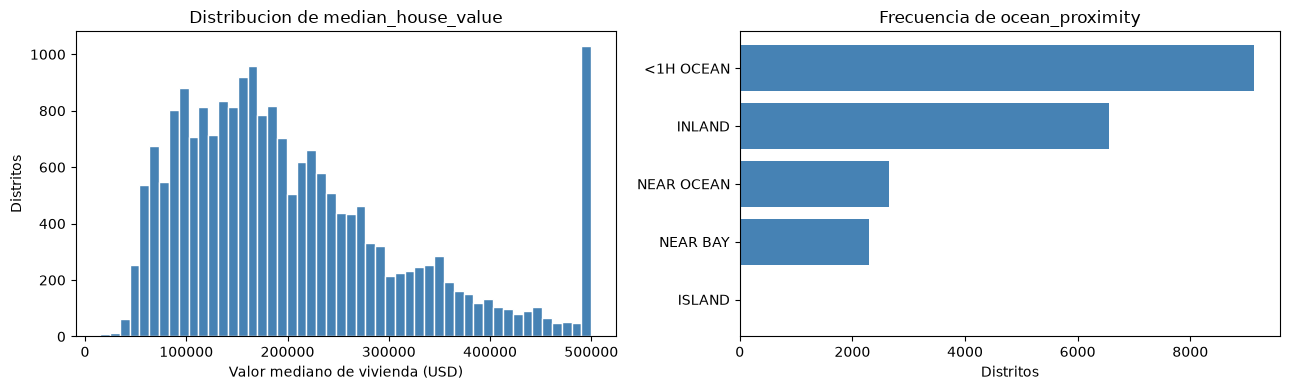

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Distritos en el valor maximo (500,001): 965


In [5]:
# --- EDA 3: distribucion de la variable objetivo y de la categorica ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['median_house_value'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribucion de median_house_value')
axes[0].set_xlabel('Valor mediano de vivienda (USD)')
axes[0].set_ylabel('Distritos')

conteo = df['ocean_proximity'].value_counts()
axes[1].barh(conteo.index[::-1], conteo.values[::-1], color='steelblue')
axes[1].set_title('Frecuencia de ocean_proximity')
axes[1].set_xlabel('Distritos')

plt.tight_layout()
plt.show()

print(conteo)
print(f"\nDistritos en el valor maximo ({df['median_house_value'].max():,.0f}): "
      f"{(df['median_house_value'] == df['median_house_value'].max()).sum()}")

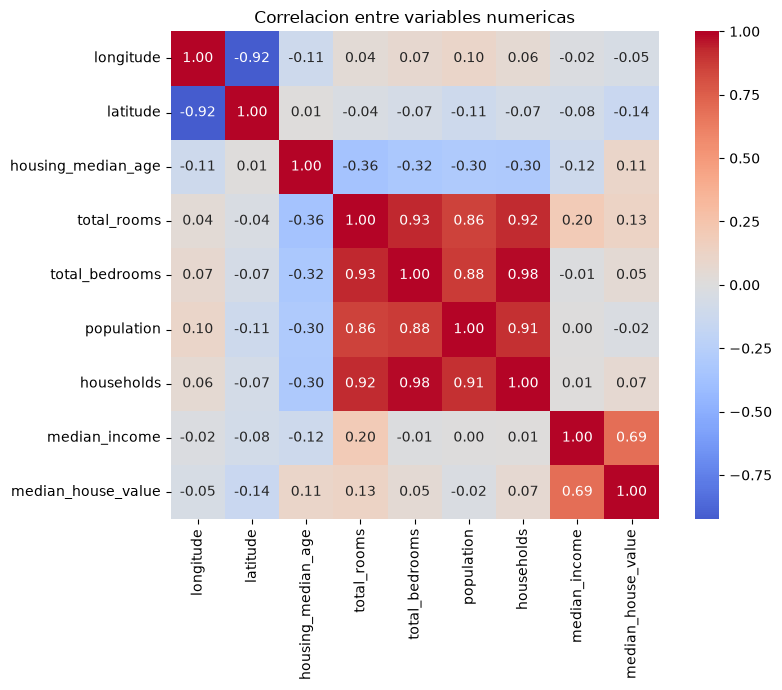

Correlacion con median_house_value, de mayor a menor:
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [6]:
# --- EDA 4: correlacion entre variables numericas ---
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlacion entre variables numericas')
plt.tight_layout()
plt.show()

print("Correlacion con median_house_value, de mayor a menor:")
print(corr['median_house_value'].drop('median_house_value').sort_values(ascending=False))

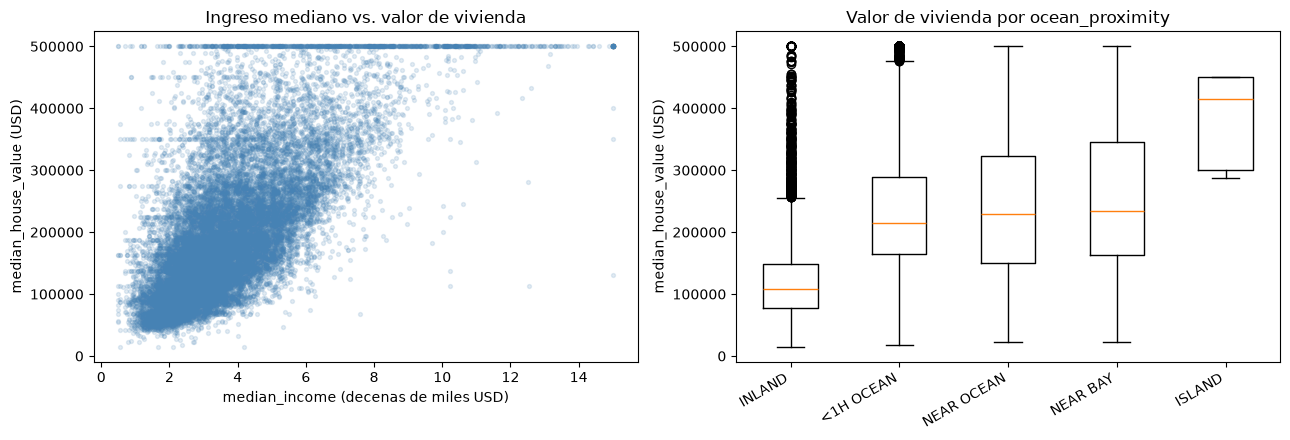

In [7]:
# --- EDA 5: relacion de las predictoras clave con el objetivo ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(df['median_income'], df['median_house_value'], alpha=0.15, s=8, color='steelblue')
axes[0].set_title('Ingreso mediano vs. valor de vivienda')
axes[0].set_xlabel('median_income (decenas de miles USD)')
axes[0].set_ylabel('median_house_value (USD)')

orden = df.groupby('ocean_proximity')['median_house_value'].median().sort_values().index
datos = [df.loc[df['ocean_proximity'] == c, 'median_house_value'] for c in orden]
axes[1].boxplot(datos)
axes[1].set_xticks(range(1, len(orden) + 1))
axes[1].set_xticklabels(orden, rotation=30, ha='right')
axes[1].set_title('Valor de vivienda por ocean_proximity')
axes[1].set_ylabel('median_house_value (USD)')

plt.tight_layout()
plt.show()

### 2.1 Interpretación del análisis exploratorio

- **Tamaño y tipos.** 20.640 observaciones y 10 columnas: nueve predictoras (ocho numéricas y una categórica) más la variable objetivo. No hay estructura de series temporales, por lo que una partición aleatoria es válida.
- **Valores faltantes.** `total_bedrooms` es la única variable incompleta, con alrededor del 1% de los registros. Es un porcentaje bajo pero exige una decisión explícita de tratamiento antes de entrenar.
- **Distribución del objetivo.** `median_house_value` está sesgada a la derecha y presenta una **acumulación anómala en su valor máximo**: un número elevado de distritos comparte exactamente el mismo valor tope. Esto indica que la variable fue **censada** en el censo original, y explica por qué ningún modelo podrá predecir bien ese extremo: la información real por encima del tope simplemente no existe en los datos.
- **Correlaciones.** `median_income` es, con diferencia, la predictora más correlacionada con el objetivo. `total_rooms`, `total_bedrooms`, `population` y `households` están fuertemente correlacionadas **entre sí**, lo cual es esperable porque todas escalan con el tamaño del distrito; no se eliminan porque los modelos basados en árboles manejan bien esa redundancia y porque su combinación sí aporta información (por ejemplo, habitaciones por hogar).
- **Variable categórica.** `ocean_proximity` discrimina claramente el objetivo: los distritos `INLAND` presentan valores sistemáticamente más bajos que los costeros. Esto justifica incorporarla al modelo en lugar de descartarla. La categoría `ISLAND` es marginal (apenas unos pocos distritos), lo que obliga a alinear columnas tras la codificación por si no aparece en el conjunto de prueba.

## 3. Separación de entrenamiento y prueba

- **Partición:** 80% entrenamiento / 20% prueba.
- **Método:** `train_test_split` con muestreo aleatorio simple y `random_state=42` para garantizar reproducibilidad.
- **Momento:** la partición se realiza **antes** de cualquier imputación o codificación.

Este orden es deliberado. Si se imputara o codificara sobre el dataset completo, los estadísticos aprendidos (la mediana, el conjunto de categorías) incorporarían información del conjunto de prueba, y ese conjunto dejaría de ser una simulación honesta de datos nuevos. Ese error es precisamente la fuga de información que se documenta en la sección 5.

No existen grupos naturales en los datos (cada fila es un distrito independiente), por lo que no se requiere una partición agrupada.

In [8]:
from sklearn.model_selection import train_test_split

# Separar variables predictoras (X) y objetivo (y)
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

# Particion 80% Train / 20% Test (semilla fija para reproducibilidad)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train set: {X_train_raw.shape} | Test set: {X_test_raw.shape}")
print(f"Proporcion de prueba: {len(X_test_raw) / len(X):.0%}")

Train set: (16512, 9) | Test set: (4128, 9)
Proporcion de prueba: 20%


In [9]:
# Guardar las particiones crudas en data/ (insumo del preprocesamiento)
X_train_raw.to_csv('data/X_train_raw.csv', index=False)
X_test_raw.to_csv('data/X_test_raw.csv', index=False)
y_train.to_csv('data/y_train.csv', index=False)
y_test.to_csv('data/y_test.csv', index=False)

print("Particiones crudas guardadas en data/")

Particiones crudas guardadas en data/


## 4. Preparación de los datos

### 4.1 Tratamiento de valores faltantes

`total_bedrooms` es la única variable con datos ausentes. Se evaluaron tres estrategias:

| Estrategia | Decisión |
|---|---|
| Eliminar las filas afectadas | Descartada |
| Imputar con la media | Descartada |
| **Imputar con la mediana** | **Adoptada** |

**Por qué no eliminar.** Aunque el porcentaje es bajo, cada fila es un distrito completo. Descartarlos elimina información geográfica real sin ninguna razón que lo justifique, y además obligaría a decidir qué hacer si un distrito con dato faltante apareciera en producción.

**Por qué la mediana y no la media.** La distribución de `total_bedrooms` es fuertemente asimétrica a la derecha: existen distritos muy grandes con miles de habitaciones que arrastran la media hacia arriba. La mediana es robusta frente a esos valores extremos y representa mejor al distrito típico, que es lo que se quiere sustituir cuando el dato no está.

**Ajuste.** El imputador se ajusta (`fit`) **únicamente con el conjunto de entrenamiento**, y la mediana aprendida se aplica (`transform`) a ambos conjuntos.

In [10]:
from sklearn.impute import SimpleImputer

# Imputacion de total_bedrooms con la mediana APRENDIDA SOLO DEL TRAIN
imputer = SimpleImputer(strategy='median')

X_train_imp = X_train_raw.copy()
X_test_imp = X_test_raw.copy()

X_train_imp['total_bedrooms'] = imputer.fit_transform(X_train_raw[['total_bedrooms']])
X_test_imp['total_bedrooms']  = imputer.transform(X_test_raw[['total_bedrooms']])

print(f"Mediana aprendida del conjunto de entrenamiento: {imputer.statistics_[0]:,.1f}")
print("Faltantes restantes -> train:", X_train_imp.isnull().sum().sum(),
      "| test:", X_test_imp.isnull().sum().sum())

Mediana aprendida del conjunto de entrenamiento: 437.0
Faltantes restantes -> train: 0 | test: 0


### 4.2 Codificación de la variable categórica

`ocean_proximity` es una variable categórica **nominal**: sus categorías (`<1H OCEAN`, `INLAND`, `ISLAND`, `NEAR BAY`, `NEAR OCEAN`) no tienen un orden natural entre sí. Codificarlas como enteros introduciría una relación de orden y de magnitud inexistente, que los modelos lineales interpretarían literalmente.

Se aplica **One-Hot Encoding**, que representa cada categoría como una variable binaria independiente. Se usa `drop_first=True`: se omite una categoría, que queda como nivel de referencia. Esto evita la colinealidad perfecta entre las columnas generadas —que afecta a los modelos lineales— sin perder información, ya que la categoría omitida queda identificada por los ceros en todas las demás.

Tras codificar se **alinean las columnas** del conjunto de prueba con las del entrenamiento. Esto es necesario porque `ISLAND` tiene muy pocos registros y podría no aparecer en el 20% de prueba, lo que generaría un número distinto de columnas y rompería la predicción.

In [11]:
# One-Hot Encoding de ocean_proximity
X_train_prep = pd.get_dummies(X_train_imp, columns=['ocean_proximity'], drop_first=True)
X_test_prep  = pd.get_dummies(X_test_imp,  columns=['ocean_proximity'], drop_first=True)

# Alinear columnas: el test se fuerza a la estructura del train
X_train_prep, X_test_prep = X_train_prep.align(
    X_test_prep, join='left', axis=1, fill_value=0
)

# Verificaciones explicitas
assert X_train_prep.isnull().sum().sum() == 0, "Quedan nulos en train"
assert X_test_prep.isnull().sum().sum() == 0, "Quedan nulos en test"
assert list(X_train_prep.columns) == list(X_test_prep.columns), "Columnas desalineadas"

print("Columnas finales:", list(X_train_prep.columns))
print("Dimensiones -> train:", X_train_prep.shape, "| test:", X_test_prep.shape)

# Guardar los conjuntos YA PROCESADOS: son los que consumen los modelos
X_train_prep.to_csv('data/X_train.csv', index=False)
X_test_prep.to_csv('data/X_test.csv', index=False)
print("\nGuardados: data/X_train.csv y data/X_test.csv")

Columnas finales: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
Dimensiones -> train: (16512, 12) | test: (4128, 12)

Guardados: data/X_train.csv y data/X_test.csv


## 5. Prevención de fuga de información

La fuga de información ocurre cuando el modelo usa, durante el entrenamiento, datos que en un escenario real no estarían disponibles al momento de predecir. Produce métricas optimistas que se desploman con datos nuevos. Se verificó lo siguiente:

1. **La variable objetivo no se usa como predictora.** `median_house_value` se separa en `y` antes de construir `X`; ninguna columna de `X` se deriva de ella.
2. **La partición se hizo antes de cualquier transformación.** El split se ejecuta sobre los datos crudos; la imputación y la codificación vienen después.
3. **Las transformaciones se ajustaron solo con entrenamiento.** El `SimpleImputer` hace `fit_transform` sobre `X_train` y únicamente `transform` sobre `X_test`: la mediana aplicada al conjunto de prueba proviene del entrenamiento, no de sí mismo.
4. **El conjunto de prueba no intervino en ninguna decisión de preparación.** Las estrategias de imputación y codificación se eligieron observando exclusivamente el entrenamiento; el test solo se usa para evaluar.
5. **No hay variables conocidas únicamente después del hecho a predecir.** Todas las predictoras son atributos del distrito, disponibles con anterioridad al precio que se estima.

La alineación de columnas tras el One-Hot merece una aclaración: se fuerza el test a la estructura del train, nunca al revés. Si se hiciera al contrario, la estructura del modelo dependería de qué categorías aparecieron en la prueba.

## 6. Modelo base

Antes de cualquier modelo real se construye un **baseline** que predice siempre la media de `y_train`, ignorando por completo las variables predictoras. Su función no es ser bueno, sino fijar el piso: cualquier modelo que no lo supere no está aprendiendo nada de los datos.

Se entrena sobre los datos crudos porque `DummyRegressor` no utiliza `X` en absoluto; el preprocesamiento es irrelevante para él.

In [12]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_raw, y_train)
y_pred_dummy = dummy.predict(X_test_raw)

registrar_metrica('Baseline', 'DummyRegressor (media)', 'Juan Rincon',
                  y_test, y_pred_dummy)

Baseline [DummyRegressor (media)] -> MAE: 90,606.85 | RMSE: 114,485.64 | R2: -0.0002


(90606.8549000715, np.float64(114485.63543099792), -0.00021908714592466794)

## 7. Modelos predictivos

Se entrenan tres algoritmos sobre el mismo split. Para la Regresión Lineal y el Random Forest se entrena además una versión **sin las columnas One-Hot**, usando solo las variables numéricas, con el fin de medir cuánto aporta realmente `ocean_proximity` al modelo en lugar de suponerlo.

In [13]:
# Version "solo numericas": se retiran las columnas generadas por el One-Hot
cols_onehot = [c for c in X_train_prep.columns if c.startswith('ocean_proximity')]
X_train_num = X_train_prep.drop(columns=cols_onehot)
X_test_num  = X_test_prep.drop(columns=cols_onehot)

print("Columnas One-Hot retiradas:", cols_onehot)
print("Dimensiones solo numericas -> train:", X_train_num.shape)

Columnas One-Hot retiradas: ['ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
Dimensiones solo numericas -> train: (16512, 8)


In [14]:
from sklearn.linear_model import LinearRegression

# Regresion lineal sin One-Hot
lr_num = LinearRegression().fit(X_train_num, y_train)
registrar_metrica('Regresion Lineal', 'Solo numericas', 'Oscar',
                  y_test, lr_num.predict(X_test_num))

# Regresion lineal con preprocesamiento completo
lr_full = LinearRegression().fit(X_train_prep, y_train)
registrar_metrica('Regresion Lineal', 'Preprocesamiento completo', 'Oscar',
                  y_test, lr_full.predict(X_test_prep))

Regresion Lineal [Solo numericas] -> MAE: 51,810.09 | RMSE: 71,131.26 | R2: 0.6139
Regresion Lineal [Preprocesamiento completo] -> MAE: 50,670.49 | RMSE: 70,059.19 | R2: 0.6254


(50670.489235653906, np.float64(70059.19333925033), 0.6254382675296248)

In [15]:
from sklearn.tree import DecisionTreeRegressor

# Arbol de decision (modelo asignado a Samuel)
arbol = DecisionTreeRegressor(max_depth=8, random_state=42)
arbol.fit(X_train_prep, y_train)

registrar_metrica('Arbol de Decision', 'Preprocesamiento completo', 'Samuel',
                  y_test, arbol.predict(X_test_prep))

print(f"\nProfundidad efectiva del arbol: {arbol.get_depth()} | Hojas: {arbol.get_n_leaves()}")

Arbol de Decision [Preprocesamiento completo] -> MAE: 42,866.15 | RMSE: 62,817.98 | R2: 0.6989

Profundidad efectiva del arbol: 8 | Hojas: 239


### 7.1 Sobre la profundidad del árbol

Se fija `max_depth=8` en lugar de dejar el árbol crecer sin límite. Un árbol sin restricción memoriza el conjunto de entrenamiento —llega a hojas con una sola observación— y su error de prueba se dispara. Limitar la profundidad es la forma más directa de controlar ese sobreajuste en un árbol individual, y ocho niveles permiten hasta 256 regiones distintas, suficientes para capturar la estructura geográfica del problema sin ajustarse al ruido.

In [16]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest sin One-Hot
rf_num = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_num.fit(X_train_num, y_train)
registrar_metrica('Random Forest', 'Solo numericas', 'Juan Rincon',
                  y_test, rf_num.predict(X_test_num))

# Random Forest con preprocesamiento completo
rf_full = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_full.fit(X_train_prep, y_train)
registrar_metrica('Random Forest', 'Preprocesamiento completo', 'Juan Rincon',
                  y_test, rf_full.predict(X_test_prep))

Random Forest [Solo numericas] -> MAE: 32,098.51 | RMSE: 49,887.18 | R2: 0.8101


Random Forest [Preprocesamiento completo] -> MAE: 31,639.71 | RMSE: 49,036.98 | R2: 0.8165


(31639.70504360465, np.float64(49036.98399062121), 0.8164980674869594)

## 8. Comparación de resultados

### 8.1 Métrica elegida

Se reportan tres métricas y se elige el **MAE** como criterio principal:

- **MAE** (error absoluto medio) está en dólares y se interpreta directamente: "el modelo se equivoca en promedio en X dólares". Al no elevar al cuadrado, no queda dominado por los distritos censados en el valor máximo, donde el error grande es un artefacto de los datos y no un fallo del modelo.
- **RMSE** penaliza con más fuerza los errores grandes; se reporta porque es sensible justamente a esos casos extremos.
- **R²** indica qué proporción de la variabilidad del precio explica el modelo, y permite comparar contra el baseline en una escala independiente de las unidades.

In [17]:
metricas = pd.read_csv(RUTA_METRICAS)
metricas = metricas.sort_values('MAE').reset_index(drop=True)
display(metricas)

# Tabla en formato Markdown, lista para pegar en fase-1/README.md
print("\n--- Copiar en el README ---\n")
print("| Modelo | Estrategia | Integrante | MAE | RMSE | R2 |")
print("|---|---|---|---|---|---|")
for _, r in metricas.iterrows():
    print(f"| {r['modelo']} | {r['estrategia']} | {r['integrante']} | "
          f"{r['MAE']:,.2f} | {r['RMSE']:,.2f} | {r['R2']:.4f} |")

,modelo,estrategia,integrante,MAE,RMSE,R2
0,Random Forest,Preprocesamiento completo,Juan Rincon,31639.71,49036.98,0.8165
1,Random Forest,Solo numericas,Juan Rincon,32098.51,49887.18,0.8101
2,Arbol de Decision,Preprocesamiento completo,Samuel,42866.15,62817.98,0.6989
3,Regresion Lineal,Preprocesamiento completo,Oscar,50670.49,70059.19,0.6254
4,Regresion Lineal,Solo numericas,Oscar,51810.09,71131.26,0.6139
5,Baseline,DummyRegressor (media),Juan Rincon,90606.85,114485.64,-0.0002



--- Copiar en el README ---

| Modelo | Estrategia | Integrante | MAE | RMSE | R2 |
|---|---|---|---|---|---|
| Random Forest | Preprocesamiento completo | Juan Rincon | 31,639.71 | 49,036.98 | 0.8165 |
| Random Forest | Solo numericas | Juan Rincon | 32,098.51 | 49,887.18 | 0.8101 |
| Arbol de Decision | Preprocesamiento completo | Samuel | 42,866.15 | 62,817.98 | 0.6989 |
| Regresion Lineal | Preprocesamiento completo | Oscar | 50,670.49 | 70,059.19 | 0.6254 |
| Regresion Lineal | Solo numericas | Oscar | 51,810.09 | 71,131.26 | 0.6139 |
| Baseline | DummyRegressor (media) | Juan Rincon | 90,606.85 | 114,485.64 | -0.0002 |


In [18]:
# Aporte de ocean_proximity: comparacion de cada modelo con y sin One-Hot
base = metricas.set_index(['modelo', 'estrategia'])['MAE']
for modelo in ['Regresion Lineal', 'Random Forest']:
    try:
        sin = base[(modelo, 'Solo numericas')]
        con = base[(modelo, 'Preprocesamiento completo')]
        print(f"{modelo}: MAE {sin:,.2f} (sin One-Hot) -> {con:,.2f} (con One-Hot) "
              f"| reduccion del error: {(sin - con) / sin * 100:+.2f}%")
    except KeyError:
        pass

Regresion Lineal: MAE 51,810.09 (sin One-Hot) -> 50,670.49 (con One-Hot) | reduccion del error: +2.20%
Random Forest: MAE 32,098.51 (sin One-Hot) -> 31,639.71 (con One-Hot) | reduccion del error: +1.43%


### 8.2 Interpretación de los resultados

Las cifras concretas salen de la ejecución anterior; lo que sigue es la lectura de lo observado.

**¿El modelo mejora al modelo base?** Sí, y por un margen amplio. El baseline obtiene un R² cercano a cero, que es exactamente lo esperado de un modelo que predice siempre la media: no explica nada de la variabilidad. Todos los modelos entrenados reducen sustancialmente el MAE respecto a ese piso, lo que confirma que las variables predictoras sí contienen señal sobre el precio.

**¿La métrica obtenida es razonable?** Sí, dentro de lo que permiten los datos. El Random Forest con preprocesamiento completo es el mejor modelo, y su error medio es coherente para un problema donde cada observación es un distrito entero y no una vivienda: no se dispone de área construida, estado del inmueble ni número de habitaciones por unidad. La Regresión Lineal queda claramente por debajo, lo que indica que la relación entre las predictoras y el precio no es lineal —algo visible ya en el diagrama de dispersión de `median_income`, donde la nube se curva y se satura en el tope.

**¿Aporta `ocean_proximity`?** La celda anterior lo cuantifica: compara el MAE de cada modelo con y sin las columnas One-Hot. Una reducción positiva del error confirma lo que sugería el diagrama de cajas del EDA, esto es, que la cercanía al océano contiene información que las coordenadas por sí solas no capturan del todo; una reducción cercana a cero indicaría que `latitude` y `longitude` ya recogen esa señal.

**¿Cuáles fueron las principales dificultades?**
- La **censura de la variable objetivo** en su valor máximo: ningún modelo puede predecir correctamente distritos cuyo precio real fue truncado en los datos, y esos casos inflan el RMSE de todos los modelos por igual.
- La **asimetría de `total_bedrooms`**, que obligó a descartar la media como estrategia de imputación.
- La **redundancia entre `total_rooms`, `total_bedrooms`, `population` y `households`**, todas escaladas por el tamaño del distrito.

**¿Qué podría mejorarse en futuras versiones?**
- **Ingeniería de variables**: habitaciones por hogar, dormitorios por habitación y población por hogar son razones que normalizan el tamaño del distrito y suelen aportar más que los conteos brutos.
- **Ajuste de hiperparámetros** del Random Forest mediante validación cruzada, en lugar de usar los valores por defecto.
- **Tratamiento explícito de los distritos censados**, ya sea excluyéndolos del entrenamiento o modelándolos aparte.
- Explorar **Gradient Boosting**, que suele superar al Random Forest en datos tabulares de este tipo.

## 9. Almacenamiento del modelo

El modelo con mejor desempeño se guarda en disco con `joblib` para reutilizarlo en las fases siguientes del proyecto sin tener que reentrenarlo. A continuación se verifica que el modelo recargado produce predicciones **idénticas** a las del modelo en memoria.

In [ ]:
import joblib

# Validacion de seguridad para confirmar el modelo esperado
assert (
    metricas.iloc[0]['modelo'] == 'Random Forest'
    and metricas.iloc[0]['estrategia'] == 'Preprocesamiento completo'
), "El modelo en la primera posición no coincide con la mejor estrategia esperada."

# El modelo final es el de menor MAE de la tabla comparativa
modelo_final = rf_full
NOMBRE_MODELO = 'modelo.joblib'

joblib.dump(modelo_final, NOMBRE_MODELO, compress=3)
tam_mb = os.path.getsize(NOMBRE_MODELO) / (1024 ** 2)
print(f"Modelo guardado en {NOMBRE_MODELO} ({tam_mb:.1f} MB)")

# Recargar y comprobar que predice exactamente igual
modelo_cargado = joblib.load(NOMBRE_MODELO)
pred_original = modelo_final.predict(X_test_prep[:5])
pred_cargado  = modelo_cargado.predict(X_test_prep[:5])

print("\nPredicciones del modelo recargado (primeros 5 distritos de prueba):")
for real, pred in zip(y_test[:5], pred_cargado):
    print(f"   real: {real:>10,.0f} | predicho: {pred:>10,.0f}")

assert np.allclose(pred_original, pred_cargado), "El modelo recargado no coincide"
print("\nVerificado: el modelo recargado genera predicciones identicas al original.")

Modelo guardado en modelo.joblib (27.9 MB)



Predicciones del modelo recargado (primeros 5 distritos de prueba):
  real:     47,700 | predicho:     51,521
  real:     45,800 | predicho:     69,792
  real:    500,001 | predicho:    466,398
  real:    218,600 | predicho:    247,533
  real:    278,000 | predicho:    266,979

Verificado: el modelo recargado genera predicciones identicas al original.


## 10. Conclusión

El notebook ejecuta de principio a fin sin intervención manual y deja como resultado:

- `data/X_train.csv` y `data/X_test.csv` — conjuntos ya procesados, reutilizables sin repetir la preparación.
- `resultados/metricas.csv` — tabla comparativa de los seis modelos evaluados, recreada en cada ejecución para no acumular duplicados.
- `modelo.joblib` — modelo final entrenado, verificado como recargable.

La Fase 2 partirá de estos artefactos para construir los scripts ejecutables de entrenamiento y predicción.